# 💧 WaterSec AI Agent — Data Exploitation & Feature Engineering
**Hackathon Notebook | Water Intelligence Platform**

Ce notebook couvre :
- 🔍 **EDA** — exploration complète des 4 datasets
- ⚙️ **Feature Engineering** — extraction de features temporelles, comportementales, hydrauliques
- 🔵 **Clustering** — K-Means + DBSCAN pour segmenter les profils d'usage
- 🚨 **Anomaly Detection** — Z-Score, IQR, Isolation Forest
- 🔗 **Pattern Detection** — séquences d'événements, corrélations inter-capteurs
- 📊 **Visualisations interactives** — Plotly


## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy import stats
from itertools import combinations

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

PALETTE = ['#0077B6', '#00B4D8', '#90E0EF', '#023E8A', '#48CAE4', '#ADE8F4', '#0096C7', '#CAF0F8']
print('✅ Imports OK')

✅ Imports OK


## 1. Chargement & Parsing des Données

In [ ]:
from pathlib import Path

# ─── Chemins datasets locaux ───────────────────────────────────────────────
root_dir = Path.cwd() if Path.cwd().name != 'notebooks' else Path.cwd().parent
DATA_DIR = (root_dir / 'data').resolve()
print('DATA_DIR =', DATA_DIR)

# ─── Gym (4 colonnes, séparateur virgule) ───────────────────────────────────
gym_raw = pd.read_csv(DATA_DIR / 'gym_consumption_data.csv')
gym_raw.columns = ['consumption', 'time', 'period', 'device']

# ─── Customers A, B, C (séparateur point-virgule) ────────────────────────────
cA_raw = pd.read_csv(DATA_DIR / 'customerA_consumption.csv', sep=';')
cB_raw = pd.read_csv(DATA_DIR / 'customerB_consumption.csv', sep=';')
cC_raw = pd.read_csv(DATA_DIR / 'customerC_consumption.csv', sep=';')

# Renommage uniforme
for df in [cA_raw, cB_raw, cC_raw]:
    df.rename(columns={'data_consumption': 'consumption',
                       'data_time': 'time',
                       'data_period': 'period'}, inplace=True)

print(f'Gym      : {gym_raw.shape}')
print(f'CustomerA: {cA_raw.shape}')
print(f'CustomerB: {cB_raw.shape}')
print(f'CustomerC: {cC_raw.shape}')

Gym      : (26982, 4)
CustomerA: (42446, 8)
CustomerB: (15346, 8)
CustomerC: (74013, 9)


## 2. Nettoyage & Prétraitement

In [3]:
def clean_df(df, source_name, has_subcategory=False):
    """
    Nettoyage standard :
    - Parse timestamps, supprime epoch 1970 (données corrompues)
    - Supprime consommations négatives
    - Ajoute colonne source
    """
    df = df.copy()
    df['time'] = pd.to_datetime(df['time'], utc=True, errors='coerce')
    df['source'] = source_name

    # Filtre timestamps aberrants (epoch 1970 ou futur > 2030)
    valid_mask = (
        df['time'].notna() &
        (df['time'].dt.year > 2020) &
        (df['time'].dt.year < 2030)
    )
    n_bad = (~valid_mask).sum()
    df = df[valid_mask].copy()

    # Supprime consommations négatives ou nulles
    df = df[df['consumption'] >= 0]

    print(f'[{source_name}] Lignes valides: {len(df)} | Supprimées (timestamp aberrant): {n_bad}')
    return df.reset_index(drop=True)


# ─── Gym : ajout des métadonnées cabin/water_type ─────────────────────────
gym_raw['time'] = pd.to_datetime(gym_raw['time'], utc=True, errors='coerce')
gym_raw['source'] = 'Gym'

# Mapping device UUID → cabin + type (8 capteurs = 4 cabines x hot/cold)
device_map = {
    '81653450-4a9c-11ef-a236-3bbfdd38639d': ('Cabin_1', 'cold'),
    '8161ea40-4a9c-11ef-82d3-2ffa8384e699': ('Cabin_1', 'hot'),
    '8170c860-4a9c-11ef-a57d-1978fe7d9161': ('Cabin_2', 'cold'),
    '81689b30-4a9c-11ef-ad50-1d2daba32da0': ('Cabin_2', 'hot'),
    '8164cb10-4a9c-11ef-b24b-055224f3eeba': ('Cabin_3', 'cold'),
    '8165a900-4a9c-11ef-8393-69e55944ae1e': ('Cabin_3', 'hot'),
    '81643740-4a9c-11ef-a595-f9c8dc6ae4ad': ('Cabin_4', 'cold'),
    '816932d0-4a9c-11ef-b3c5-85b5ce342d21': ('Cabin_4', 'hot'),
}
gym_raw[['cabin', 'water_type']] = gym_raw['device'].map(device_map).apply(pd.Series)
gym_raw['main_category_name'] = 'Shower'
gym_raw['sub_category_name']  = gym_raw['cabin']
gym_raw['tag'] = gym_raw['water_type']

gym = clean_df(gym_raw[['consumption','time','period','device','source',
                         'main_category_name','sub_category_name','tag']], 'Gym')

# ─── Customers ────────────────────────────────────────────────────────────
cA = clean_df(cA_raw, 'CustomerA')
cB = clean_df(cB_raw, 'CustomerB')
cC = clean_df(cC_raw, 'CustomerC')

# Ajouter sub_category_name manquant pour A et B
for df in [cA, cB]:
    if 'sub_category_name' not in df.columns:
        df['sub_category_name'] = df['main_category_name']

# ─── Dataset unifié ───────────────────────────────────────────────────────
common_cols = ['consumption','time','period','device','source',
               'main_category_name','sub_category_name','tag']
df_all = pd.concat([gym[common_cols], cA[common_cols],
                    cB[common_cols], cC[common_cols]], ignore_index=True)

print(f'\n✅ Dataset unifié: {df_all.shape[0]:,} enregistrements')

[Gym] Lignes valides: 26633 | Supprimées (timestamp aberrant): 349
[CustomerA] Lignes valides: 42442 | Supprimées (timestamp aberrant): 4
[CustomerB] Lignes valides: 15342 | Supprimées (timestamp aberrant): 4
[CustomerC] Lignes valides: 73934 | Supprimées (timestamp aberrant): 79

✅ Dataset unifié: 158,351 enregistrements


## 3. EDA — Exploration des Données

In [4]:
# ─── Vue d'ensemble ────────────────────────────────────────────────────────
print('=== STATS GLOBALES ===')
print(df_all.groupby('source')['consumption'].agg(['count','mean','median','std','max']).round(1))

=== STATS GLOBALES ===
           count      mean  median         std         max
source                                                    
CustomerA  42442 508471.50 1207.00 46615058.90  4294967295
CustomerB  15342  13996.30 6392.00   129913.60    11132519
CustomerC  73934   2192.30  768.00    20226.80     4580539
Gym        26633   6108.20 2554.00     9085.70      172072


In [27]:
# ─── Distribution des consommations par source ──────────────────────────
fig = make_subplots(rows=2, cols=2,
                    subplot_titles=['Gym','CustomerA','CustomerB','CustomerC'])

for i, (src, color) in enumerate([('Gym','#0077B6'),('CustomerA','#00B4D8'),
                                   ('CustomerB','#0096C7'),('CustomerC','#023E8A')]):
    row, col = divmod(i, 2)
    sub = df_all[df_all['source'] == src]['consumption']
    sub_clipped = sub[sub < sub.quantile(0.99)]  # clip outliers extrêmes
    fig.add_trace(go.Histogram(x=sub_clipped, nbinsx=60, name=src,
                               marker_color=color, opacity=0.8),
                  row=row+1, col=col+1)

fig.update_layout(title='Distribution des consommations (cl) par source',
                  height=600, showlegend=False)
fig.show()

In [28]:
# ─── Consommation journalière globale ──────────────────────────────────────
df_all['date'] = df_all['time'].dt.date
daily = df_all.groupby(['date','source'])['consumption'].sum().reset_index()

fig = px.line(daily, x='date', y='consumption', color='source',
              title='Consommation journalière totale par source (cl)',
              color_discrete_sequence=PALETTE)
fig.update_layout(xaxis_title='Date', yaxis_title='Consommation (cl)')
fig.show()

In [29]:
# ─── Profil horaire moyen (heatmap heure x jour) ────────────────────────
df_all['hour'] = df_all['time'].dt.hour
df_all['dow']  = df_all['time'].dt.day_name()

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

for src in df_all['source'].unique():
    sub = df_all[df_all['source'] == src].copy()
    pivot = sub.pivot_table(values='consumption', index='hour', columns='dow',
                            aggfunc='mean')[day_order]
    fig = px.imshow(pivot, color_continuous_scale='Blues',
                    title=f'Heatmap consommation horaire — {src}',
                    labels={'x':'Jour','y':'Heure','color':'Consommation moy (cl)'})
    fig.update_layout(height=400)
    fig.show()

In [8]:
# ─── Gym : comparaison cabines & hot/cold ────────────────────────────────
gym_agg = gym.groupby(['sub_category_name','tag'])['consumption'].sum().reset_index()

fig = px.bar(gym_agg, x='sub_category_name', y='consumption', color='tag',
             barmode='group', title='Gym — Consommation totale par cabine (hot vs cold)',
             color_discrete_map={'hot':'#FF6B6B','cold':'#0077B6'},
             labels={'consumption':'Consommation totale (cl)','sub_category_name':'Cabine'})
fig.show()

In [9]:
# ─── CustomerC : répartition par sous-catégorie (Flush / Sink / Tap) ─────
cC_agg = cC.groupby('sub_category_name')['consumption'].agg(['sum','count','mean']).reset_index()
fig = px.pie(cC_agg, names='sub_category_name', values='sum',
             title='CustomerC — Part de chaque usage (volume total)',
             color_discrete_sequence=PALETTE)
fig.show()

print(cC_agg.round(1))

  sub_category_name        sum  count    mean
0             Flush  126696300  23081 5489.20
1              Sink   19179403  31736  604.30
2               Tap   16206395  19117  847.70


## 4. Feature Engineering Avancé

In [10]:
def engineer_features(df):
    """
    Génère un ensemble riche de features à partir d'un dataframe nettoyé.
    """
    df = df.copy().sort_values('time')

    # ── Features temporelles ───────────────────────────────────────────────
    df['hour']        = df['time'].dt.hour
    df['minute']      = df['time'].dt.minute
    df['dow']         = df['time'].dt.dayofweek        # 0=Lundi, 6=Dimanche
    df['month']       = df['time'].dt.month
    df['week']        = df['time'].dt.isocalendar().week.astype(int)
    df['is_weekend']  = (df['dow'] >= 5).astype(int)
    df['date']        = df['time'].dt.date

    # Plages horaires
    bins   = [0, 6, 9, 12, 14, 18, 21, 24]
    labels = ['Nuit','Matin_tôt','Matin','Midi','Après-midi','Soir','Soirée']
    df['time_slot'] = pd.cut(df['hour'], bins=bins, labels=labels, right=False)

    # ── Features hydrauliques / débit ─────────────────────────────────────
    # flow_rate = consommation / durée de la période (cl/s)
    df['flow_rate'] = np.where(df['period'] > 0,
                               df['consumption'] / df['period'], np.nan)

    # ── Features par device (contexte) ────────────────────────────────────
    df = df.sort_values(['device','time'])
    df['inter_event_sec'] = (
        df.groupby('device')['time']
          .diff()
          .dt.total_seconds()
    )
    # Indicateur de session continue (< 5 min depuis dernier événement)
    df['same_session'] = (df['inter_event_sec'] < 300).astype(int)

    # Rolling stats par device (fenêtre 7 derniers événements)
    df['rolling_mean_7']   = df.groupby('device')['consumption'].transform(
                                lambda x: x.rolling(7, min_periods=1).mean())
    df['rolling_std_7']    = df.groupby('device')['consumption'].transform(
                                lambda x: x.rolling(7, min_periods=1).std().fillna(0))
    df['rolling_max_7']    = df.groupby('device')['consumption'].transform(
                                lambda x: x.rolling(7, min_periods=1).max())

    # Z-score local par device
    df['z_score'] = df.groupby('device')['consumption'].transform(
                        lambda x: (x - x.mean()) / (x.std() + 1e-9))

    # ── Agrégat journalier par device (pivot back) ─────────────────────────
    day_agg = df.groupby(['device','date']).agg(
        daily_total   = ('consumption','sum'),
        daily_events  = ('consumption','count'),
        daily_mean    = ('consumption','mean'),
        daily_max     = ('consumption','max'),
        daily_flow    = ('flow_rate','mean'),
    ).reset_index()
    df = df.merge(day_agg, on=['device','date'], how='left')

    return df


print('Engineering features pour chaque source...')
gym_fe  = engineer_features(gym)
cA_fe   = engineer_features(cA)
cB_fe   = engineer_features(cB)
cC_fe   = engineer_features(cC)

print(f'Gym FE shape  : {gym_fe.shape}')
print(f'CustomerC FE  : {cC_fe.shape}')
print('\nAperçu features CustomerC :')
print(cC_fe[['time','sub_category_name','consumption','flow_rate',
             'time_slot','z_score','rolling_mean_7','daily_total']].head(8))

Engineering features pour chaque source...
Gym FE shape  : (26633, 28)
CustomerC FE  : (73934, 30)

Aperçu features CustomerC :
                       time sub_category_name  consumption  flow_rate  \
0 2024-03-05 14:57:20+00:00              Sink          262      65.50   
1 2024-03-07 03:43:13+00:00              Sink           80       1.90   
2 2024-03-07 07:35:10+00:00              Sink         2234      85.92   
3 2024-03-07 07:42:11+00:00              Sink         1871     124.73   
4 2024-03-07 07:52:37+00:00              Sink         2209     122.72   
5 2024-03-07 07:56:47+00:00              Sink         1887     125.80   
6 2024-03-07 08:17:10+00:00              Sink          289      72.25   
7 2024-03-07 08:17:51+00:00              Sink         1884     117.75   

    time_slot  z_score  rolling_mean_7  daily_total  
0  Après-midi    -0.44          262.00          262  
1        Nuit    -0.63          171.00        80875  
2   Matin_tôt     1.70          858.67        80875 

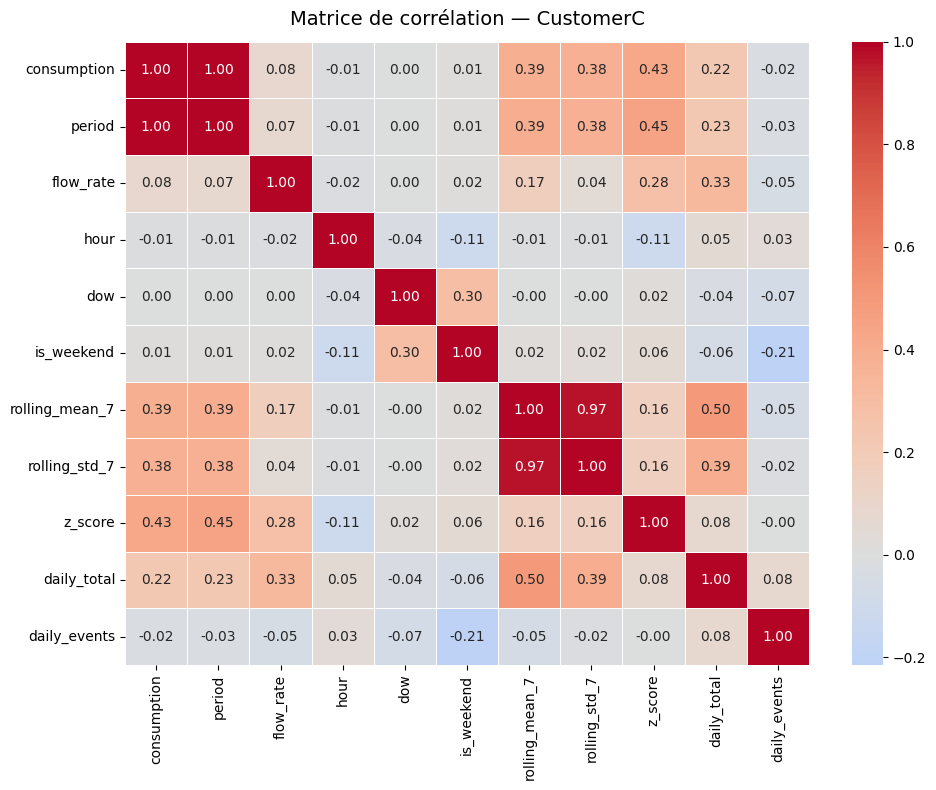

In [11]:
# ─── Feature importance visuelle : corrélation ─────────────────────────────
num_cols = ['consumption','period','flow_rate','hour','dow','is_weekend',
            'rolling_mean_7','rolling_std_7','z_score','daily_total','daily_events']

corr = cC_fe[num_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Matrice de corrélation — CustomerC', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

In [12]:
# ─── Profil de débit horaire (flow_rate) Gym hot vs cold ─────────────────
gym_flow = gym_fe.groupby(['hour','tag'])['flow_rate'].mean().reset_index()

fig = px.line(gym_flow, x='hour', y='flow_rate', color='tag',
              title='Gym — Débit moyen (cl/s) par heure : Hot vs Cold',
              color_discrete_map={'hot':'#FF6B6B','cold':'#0077B6'},
              markers=True)
fig.update_layout(xaxis=dict(tickmode='linear', tick0=0, dtick=1))
fig.show()

## 5. Clustering — K-Means & DBSCAN

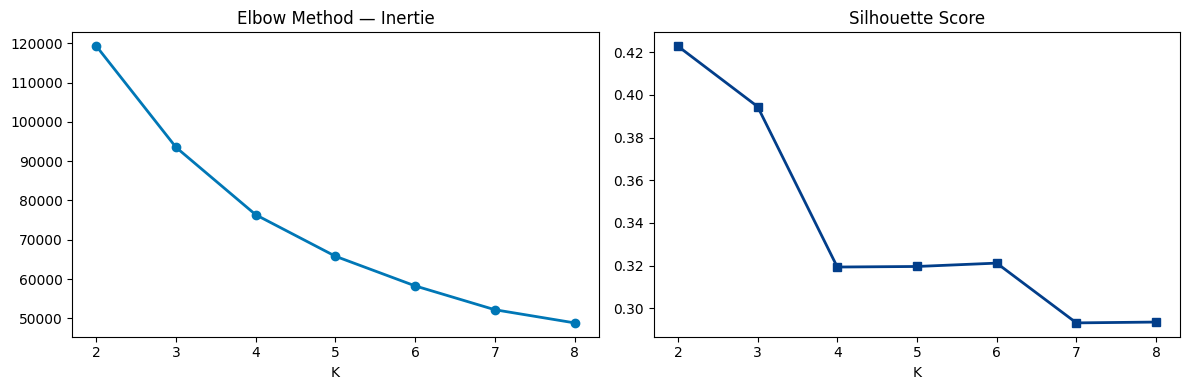

K optimal (silhouette) = 2


In [13]:
# ─── 5.1 Clustering des sessions de douche (Gym) ─────────────────────────
# Features : consommation, débit, durée (period), heure, jour

gym_cluster = gym_fe[['consumption','flow_rate','period','hour','dow','is_weekend',
                       'sub_category_name','tag']].dropna().copy()

features_gym = ['consumption','flow_rate','period','hour','dow','is_weekend']
X_gym = gym_cluster[features_gym].values

scaler = StandardScaler()
X_gym_scaled = scaler.fit_transform(X_gym)

# ── Elbow method pour K optimal ──────────────────────────────────────────
inertias, silhouettes = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_gym_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_gym_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_range), inertias, 'o-', color='#0077B6', lw=2)
axes[0].set_title('Elbow Method — Inertie'); axes[0].set_xlabel('K')
axes[1].plot(list(K_range), silhouettes, 's-', color='#023E8A', lw=2)
axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('K')
plt.tight_layout(); plt.show()

best_k = list(K_range)[np.argmax(silhouettes)]
print(f'K optimal (silhouette) = {best_k}')

In [14]:
# ── K-Means final ────────────────────────────────────────────────────────
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
gym_cluster['cluster_kmeans'] = km_final.fit_predict(X_gym_scaled)

# Réduction PCA pour visualisation 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_gym_scaled)
gym_cluster['pca1'] = X_pca[:,0]
gym_cluster['pca2'] = X_pca[:,1]

fig = px.scatter(gym_cluster, x='pca1', y='pca2',
                 color=gym_cluster['cluster_kmeans'].astype(str),
                 symbol='tag', hover_data=features_gym,
                 title=f'K-Means (K={best_k}) — Gym Sessions (PCA 2D)',
                 color_discrete_sequence=PALETTE,
                 labels={'pca1':'PC1','pca2':'PC2','color':'Cluster'})
fig.update_traces(marker=dict(size=5, opacity=0.7))
fig.show()

# Profil de chaque cluster
print('\nProfil moyen par cluster K-Means (Gym):')
print(gym_cluster.groupby('cluster_kmeans')[features_gym].mean().round(2))


Profil moyen par cluster K-Means (Gym):
                consumption  flow_rate  period  hour  dow  is_weekend
cluster_kmeans                                                       
0                   6111.52      79.62   85.27 16.00 1.98        0.00
1                   6089.99      93.04   78.64 12.08 5.26        1.00


In [15]:
# ─── 5.2 DBSCAN sur CustomerC ─────────────────────────────────────────────
# Objectif : détecter les clusters naturels d'usage (densité) + outliers

cC_cluster = cC_fe[['consumption','flow_rate','hour','dow','daily_total',
                     'daily_events','sub_category_name']].dropna().copy()

features_cC = ['consumption','flow_rate','hour','dow','daily_total','daily_events']
X_cC = cC_cluster[features_cC].values
X_cC_scaled = StandardScaler().fit_transform(X_cC)

db = DBSCAN(eps=0.8, min_samples=15, metric='euclidean')
cC_cluster['cluster_dbscan'] = db.fit_predict(X_cC_scaled)

n_clusters = len(set(cC_cluster['cluster_dbscan'])) - (1 if -1 in cC_cluster['cluster_dbscan'].values else 0)
n_noise    = (cC_cluster['cluster_dbscan'] == -1).sum()
print(f'DBSCAN → {n_clusters} clusters | {n_noise} points bruit ({n_noise/len(cC_cluster)*100:.1f}%)')

# PCA 2D
pca2 = PCA(n_components=2, random_state=42)
X_cC_pca = pca2.fit_transform(X_cC_scaled)
cC_cluster['pca1'] = X_cC_pca[:,0]
cC_cluster['pca2'] = X_cC_pca[:,1]
cC_cluster['label'] = cC_cluster['cluster_dbscan'].apply(
    lambda x: 'Noise' if x == -1 else f'Cluster {x}')

fig = px.scatter(cC_cluster.sample(min(5000, len(cC_cluster)), random_state=42),
                 x='pca1', y='pca2', color='label',
                 symbol='sub_category_name', opacity=0.6,
                 title='DBSCAN — CustomerC Residential (PCA 2D)',
                 color_discrete_sequence=PALETTE + ['#FF6B6B'])
fig.update_traces(marker=dict(size=5))
fig.show()

DBSCAN → 8 clusters | 185 points bruit (0.3%)


In [16]:
# ─── 5.3 Clustering journalier multi-source ───────────────────────────────
# Profil journalier agrégé par device + source

all_fe = pd.concat([
    gym_fe.assign(source='Gym'),
    cA_fe.assign(source='CustomerA'),
    cB_fe.assign(source='CustomerB'),
    cC_fe.assign(source='CustomerC'),
], ignore_index=True)

all_fe['date'] = all_fe['time'].dt.date

daily_profile = all_fe.groupby(['device','date','source']).agg(
    total     = ('consumption','sum'),
    events    = ('consumption','count'),
    mean_cons = ('consumption','mean'),
    max_cons  = ('consumption','max'),
    mean_flow = ('flow_rate','mean'),
    peak_hour = ('hour', lambda x: x.value_counts().idxmax() if len(x) > 0 else np.nan),
).reset_index().dropna()

feat_daily = ['total','events','mean_cons','max_cons','mean_flow','peak_hour']
X_daily = StandardScaler().fit_transform(daily_profile[feat_daily])

km_daily = KMeans(n_clusters=4, random_state=42, n_init=10)
daily_profile['cluster'] = km_daily.fit_predict(X_daily)

pca_d = PCA(n_components=2, random_state=42)
X_d_pca = pca_d.fit_transform(X_daily)
daily_profile['pca1'] = X_d_pca[:,0]
daily_profile['pca2'] = X_d_pca[:,1]

fig = px.scatter(daily_profile, x='pca1', y='pca2',
                 color='source', symbol=daily_profile['cluster'].astype(str),
                 title='Clustering journalier multi-source (K=4, PCA 2D)',
                 color_discrete_sequence=PALETTE,
                 labels={'symbol':'Cluster','pca1':'PC1','pca2':'PC2'},
                 hover_data=['total','events','mean_flow'])
fig.update_traces(marker=dict(size=6, opacity=0.7))
fig.show()

## 6. Détection d'Anomalies

In [17]:
# ─── 6.1 Z-Score global par device ───────────────────────────────────────
def detect_anomalies_zscore(df, threshold=3.0):
    df = df.copy()
    df['anomaly_zscore'] = (np.abs(df['z_score']) > threshold).astype(int)
    return df

# ─── 6.2 IQR par device ──────────────────────────────────────────────────
def detect_anomalies_iqr(df):
    df = df.copy()
    def iqr_flag(x):
        Q1, Q3 = x.quantile(0.25), x.quantile(0.75)
        IQR = Q3 - Q1
        return ((x < Q1 - 1.5*IQR) | (x > Q3 + 1.5*IQR)).astype(int)
    df['anomaly_iqr'] = df.groupby('device')['consumption'].transform(iqr_flag)
    return df

# ─── 6.3 Isolation Forest ─────────────────────────────────────────────────
def detect_anomalies_iforest(df, features, contamination=0.03):
    df = df.copy()
    sub = df[features].dropna()
    iso = IsolationForest(contamination=contamination, random_state=42, n_estimators=100)
    pred = iso.fit_predict(sub)
    df.loc[sub.index, 'anomaly_iforest'] = (pred == -1).astype(int)
    df['anomaly_iforest'] = df['anomaly_iforest'].fillna(0).astype(int)
    return df


# Appliquer sur CustomerC
cC_anom = detect_anomalies_zscore(cC_fe)
cC_anom = detect_anomalies_iqr(cC_anom)
feats_iso = ['consumption','flow_rate','period','hour','dow','daily_total']
cC_anom = detect_anomalies_iforest(cC_anom, feats_iso)

# Consensus : anomalie si ≥ 2 méthodes la détectent
cC_anom['anomaly_score'] = (cC_anom['anomaly_zscore'] +
                             cC_anom['anomaly_iqr'] +
                             cC_anom['anomaly_iforest'])
cC_anom['is_anomaly'] = (cC_anom['anomaly_score'] >= 2).astype(int)

print('CustomerC — Anomalies détectées (consensus ≥2 méthodes):')
print(cC_anom.groupby('sub_category_name')['is_anomaly'].sum())
print(f'\nTotal anomalies: {cC_anom["is_anomaly"].sum()} / {len(cC_anom)} '
      f'({cC_anom["is_anomaly"].mean()*100:.1f}%)')

CustomerC — Anomalies détectées (consensus ≥2 méthodes):
sub_category_name
Flush    1449
Sink      456
Tap       495
Name: is_anomaly, dtype: int64

Total anomalies: 2400 / 73934 (3.2%)


In [18]:
# ─── Visualisation anomalies CustomerC (timeline) ────────────────────────
cC_anom_plot = cC_anom.sort_values('time')

fig = go.Figure()
for sub_cat, color in zip(['Flush','Sink','Tap'], ['#0077B6','#00B4D8','#023E8A']):
    normal  = cC_anom_plot[(cC_anom_plot['sub_category_name']==sub_cat) & (cC_anom_plot['is_anomaly']==0)]
    anom    = cC_anom_plot[(cC_anom_plot['sub_category_name']==sub_cat) & (cC_anom_plot['is_anomaly']==1)]
    fig.add_trace(go.Scatter(x=normal['time'], y=normal['consumption'],
                             mode='markers', name=f'{sub_cat} (normal)',
                             marker=dict(color=color, size=3, opacity=0.4)))
    fig.add_trace(go.Scatter(x=anom['time'], y=anom['consumption'],
                             mode='markers', name=f'{sub_cat} (ANOMALIE)',
                             marker=dict(color='#FF4444', size=8, symbol='x', opacity=0.9)))

fig.update_layout(title='CustomerC — Détection d\'anomalies (consensus multi-méthodes)',
                  xaxis_title='Date', yaxis_title='Consommation (cl)', height=500)
fig.show()

In [19]:
# ─── Anomalies Gym : consommations nocturnes (hors heures d'ouverture) ────
# Un gym n'est typiquement pas ouvert entre 23h et 6h
gym_anom = gym_fe.copy()
gym_anom['night_usage'] = ((gym_anom['hour'] >= 23) | (gym_anom['hour'] < 6)).astype(int)
gym_anom['anomaly_zscore'] = (np.abs(gym_anom['z_score']) > 3).astype(int)

night = gym_anom[gym_anom['night_usage'] == 1]
print(f'Gym — Événements nocturnes (23h-6h): {len(night)}')
print(night.groupby(['sub_category_name','tag'])[['consumption','flow_rate']].agg(['count','mean']).round(2))

fig = px.histogram(night, x='hour', color='tag',
                   title='Gym — Distribution horaire des usages nocturnes (anomalies potentielles)',
                   color_discrete_map={'hot':'#FF6B6B','cold':'#0077B6'},
                   barmode='group')
fig.show()

Gym — Événements nocturnes (23h-6h): 532
                       consumption          flow_rate       
                             count     mean     count   mean
sub_category_name tag                                       
Cabin_1           cold           8  1526.38         8  43.25
                  hot          306  3727.50       306 215.81
Cabin_2           cold          12  3567.08        12  57.64
                  hot           64 13948.33        64  78.38
Cabin_3           cold          21  1296.90        21  41.97
                  hot           14  3068.14        14  68.05
Cabin_4           cold          51  4941.63        51  56.90
                  hot           56 17875.23        56  78.21


## 7. Pattern Detection — Séquences & Comportements

In [20]:
# ─── 7.1 Patterns séquentiels CustomerC (Flush → Sink) ────────────────────
# Hypothèse : un flush est souvent suivi d'un lavage de mains (sink)
# On détecte les paires Flush→Sink dans une fenêtre de 2 minutes

cC_seq = cC_fe[['time','device','sub_category_name','consumption']].copy()
cC_seq = cC_seq.sort_values('time')

# Séparer les events par type
flush_events = cC_seq[cC_seq['sub_category_name'] == 'Flush'][['time','consumption']].copy()
sink_events  = cC_seq[cC_seq['sub_category_name'] == 'Sink'][['time','consumption']].copy()
tap_events   = cC_seq[cC_seq['sub_category_name'] == 'Tap'][['time','consumption']].copy()

flush_events.columns = ['flush_time','flush_cons']
sink_events.columns  = ['sink_time','sink_cons']

# Merge avec tolérance temporelle (merge_asof)
flush_sorted = flush_events.sort_values('flush_time')
sink_sorted  = sink_events.sort_values('sink_time')

pairs = pd.merge_asof(
    flush_sorted,
    sink_sorted,
    left_on='flush_time', right_on='sink_time',
    direction='forward',
    tolerance=pd.Timedelta('2min')
).dropna(subset=['sink_time'])

pairs['delay_sec'] = (pairs['sink_time'] - pairs['flush_time']).dt.total_seconds()

print(f'Paires Flush→Sink (≤2 min) détectées: {len(pairs)}')
print(f'Délai moyen Flush→Sink: {pairs["delay_sec"].mean():.1f}s')
print(f'Délai médian: {pairs["delay_sec"].median():.1f}s')

fig = px.histogram(pairs, x='delay_sec', nbins=40,
                   title='CustomerC — Distribution du délai Flush → Sink (secondes)',
                   color_discrete_sequence=['#0077B6'],
                   labels={'delay_sec':'Délai (secondes)'})
fig.add_vline(x=pairs['delay_sec'].median(), line_dash='dash',
              line_color='#FF6B6B', annotation_text='Médiane')
fig.show()

Paires Flush→Sink (≤2 min) détectées: 7395
Délai moyen Flush→Sink: 46.5s
Délai médian: 39.0s


In [21]:
# ─── 7.2 Patterns récurrents horaires (CustomerC) ─────────────────────────
# Trouver les créneaux horaires avec usage concentré

cC_hourly = cC_fe.groupby(['hour','sub_category_name'])['consumption'].agg(
    ['sum','count','mean']).reset_index()

fig = px.bar(cC_hourly, x='hour', y='mean', color='sub_category_name',
             barmode='group',
             title='CustomerC — Consommation moyenne (cl) par heure et type',
             color_discrete_sequence=PALETTE,
             labels={'mean':'Consommation moy (cl)','hour':'Heure','sub_category_name':'Type'})
fig.update_layout(xaxis=dict(tickmode='linear', tick0=0, dtick=1))
fig.show()

In [22]:
# ─── 7.3 Patterns hebdomadaires (gym) ─────────────────────────────────────
# Y a-t-il des jours de pic ? Week-end vs semaine ?

gym_weekly = gym_fe.groupby(['dow','sub_category_name','tag'])['consumption'].sum().reset_index()
day_labels = {0:'Lun',1:'Mar',2:'Mer',3:'Jeu',4:'Ven',5:'Sam',6:'Dim'}
gym_weekly['day_name'] = gym_weekly['dow'].map(day_labels)

fig = px.bar(gym_weekly[gym_weekly['tag']=='cold'],
             x='day_name', y='consumption', color='sub_category_name',
             barmode='group',
             title='Gym — Consommation eau froide par jour de semaine & cabine',
             color_discrete_sequence=PALETTE,
             category_orders={'day_name':['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']},
             labels={'consumption':'Volume total (cl)','day_name':'Jour'})
fig.show()

In [23]:
# ─── 7.4 Détection de tendances : rolling 7 jours (CustomerB) ────────────
cB_daily = cB_fe.groupby('date')['consumption'].sum().reset_index()
cB_daily['date']      = pd.to_datetime(cB_daily['date'])
cB_daily['roll7']     = cB_daily['consumption'].rolling(7, center=True).mean()
cB_daily['roll7_std'] = cB_daily['consumption'].rolling(7, center=True).std()

fig = go.Figure()
fig.add_trace(go.Bar(x=cB_daily['date'], y=cB_daily['consumption'],
                     name='Journalier', marker_color='#90E0EF', opacity=0.6))
fig.add_trace(go.Scatter(x=cB_daily['date'], y=cB_daily['roll7'],
                         name='Moyenne mobile 7j', line=dict(color='#023E8A', width=2)))
fig.add_trace(go.Scatter(
    x=pd.concat([cB_daily['date'], cB_daily['date'][::-1]]),
    y=pd.concat([cB_daily['roll7']+cB_daily['roll7_std'],
                 (cB_daily['roll7']-cB_daily['roll7_std'])[::-1]]),
    fill='toself', fillcolor='rgba(0,119,182,0.15)',
    line=dict(color='rgba(0,0,0,0)'), name='±1σ'
))
fig.update_layout(title='CustomerB — Tendance journalière + bande de confiance',
                  xaxis_title='Date', yaxis_title='Consommation (cl)', height=450)
fig.show()

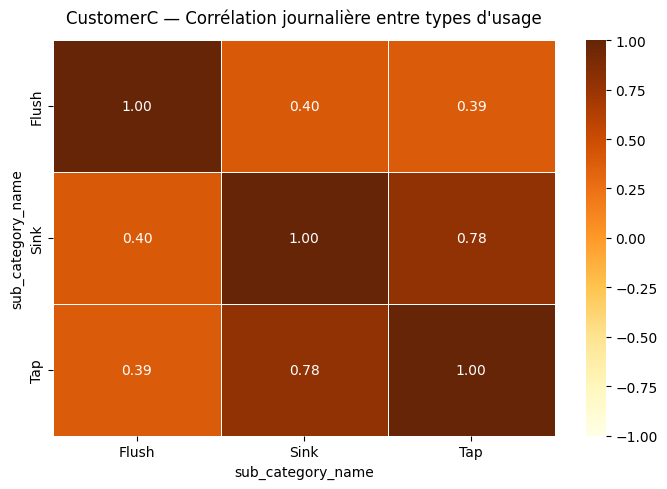

Pearson Flush↔Sink : r=0.400, p=0.0000


In [24]:
# ─── 7.5 Corrélation inter-capteurs CustomerC ─────────────────────────────
# Est-ce que le flush et le sink sont corrélés au niveau journalier ?

cC_pivot = cC_fe.groupby(['date','sub_category_name'])['consumption'].sum().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cC_pivot.corr(), annot=True, fmt='.2f', cmap='YlOrBr', ax=ax,
            linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('CustomerC — Corrélation journalière entre types d\'usage', pad=12)
plt.tight_layout(); plt.show()

# Scatter Flush vs Sink
if 'Flush' in cC_pivot.columns and 'Sink' in cC_pivot.columns:
    r, p = stats.pearsonr(cC_pivot['Flush'], cC_pivot['Sink'])
    print(f'Pearson Flush↔Sink : r={r:.3f}, p={p:.4f}')
    fig = px.scatter(cC_pivot.reset_index(), x='Flush', y='Sink',
                     trendline='ols',
                     title=f'CustomerC — Flush vs Sink journalier (r={r:.2f})',
                     color_discrete_sequence=['#0077B6'])
    fig.show()

## 8. Synthèse & Insights Water Domain

In [25]:
# ─── Tableau de bord récapitulatif ────────────────────────────────────────
summary = []
for src, df_src in [('Gym', gym_fe), ('CustomerA', cA_fe),
                    ('CustomerB', cB_fe), ('CustomerC', cC_fe)]:
    n_days    = df_src['time'].dt.date.nunique()
    total_cl  = df_src['consumption'].sum()
    avg_daily = total_cl / max(n_days, 1)
    peak_h    = df_src.groupby('hour')['consumption'].sum().idxmax()
    n_anom_z  = (np.abs(df_src['z_score']) > 3).sum()
    summary.append({
        'Source': src,
        'Jours de données': n_days,
        'Volume total (cl)': f'{total_cl:,.0f}',
        'Moy. journalière (cl)': f'{avg_daily:,.0f}',
        'Heure de pic': f'{peak_h}h',
        'Anomalies Z>3': n_anom_z,
    })

summary_df = pd.DataFrame(summary)
print('\n' + '='*70)
print('TABLEAU DE BORD WATERSEC — RÉSUMÉ EXÉCUTIF')
print('='*70)
print(summary_df.to_string(index=False))


TABLEAU DE BORD WATERSEC — RÉSUMÉ EXÉCUTIF
   Source  Jours de données Volume total (cl) Moy. journalière (cl) Heure de pic  Anomalies Z>3
      Gym               509       162,679,600               319,606          21h            524
CustomerA               157    21,580,549,021           137,455,726          13h            389
CustomerB               171       214,731,342             1,255,739          12h             14
CustomerC               540       162,082,098               300,152           9h            959


In [26]:
# ─── Insights automatiques ─────────────────────────────────────────────────
print('\n💡 INSIGHTS WATER DOMAIN\n')

# 1. Ratio hot/cold gym
hot_total  = gym[gym['tag']=='hot']['consumption'].sum()
cold_total = gym[gym['tag']=='cold']['consumption'].sum()
ratio = hot_total / (hot_total + cold_total) * 100
print(f'🌡️  Gym — Eau chaude représente {ratio:.1f}% de la consommation totale douches')

# 2. Pic d'activité résidentiel
cC_peak = cC_fe.groupby('hour')['consumption'].sum()
peak_h   = cC_peak.idxmax()
print(f'🏠 Résidentiel (CustomerC) — Pic de consommation à {peak_h}h00')

# 3. Paires Flush->Sink
if len(pairs) > 0:
    pct_linked = len(pairs) / len(flush_events) * 100
    print(f'🔗 {pct_linked:.0f}% des flush sont suivis d\'un lavage de mains (≤2min)')

# 4. Cabine gym la plus utilisée
top_cabin = gym.groupby('sub_category_name')['consumption'].sum().idxmax()
print(f'🚿 Cabine la plus consommatrice : {top_cabin}')

# 5. Anomalies
n_cC_anom = cC_anom['is_anomaly'].sum() if 'is_anomaly' in cC_anom.columns else 0
print(f'⚠️  CustomerC — {n_cC_anom} événements anormaux détectés (consensus 3 méthodes)')

print('\n✅ Analyse complète terminée.')


💡 INSIGHTS WATER DOMAIN

🌡️  Gym — Eau chaude représente 68.5% de la consommation totale douches
🏠 Résidentiel (CustomerC) — Pic de consommation à 9h00
🔗 32% des flush sont suivis d'un lavage de mains (≤2min)
🚿 Cabine la plus consommatrice : Cabin_4
⚠️  CustomerC — 2400 événements anormaux détectés (consensus 3 méthodes)

✅ Analyse complète terminée.
